In [5]:
]activate ../../../../

  Activating project at `~/UCLOneDrive/SpatialStructureInMicrobialCommunities/SSMCCode`

In [6]:
using Revise
includet("./base.jl")

In [7]:
using ColorSchemes

In [8]:
using CairoMakie
CairoMakie.activate!()

# Load

In [48]:
datadir = "data"

setup = load("systems.jld2")
pde_df = setup["pde_df"]
smeta = setup["metadata"]

runs = collect_pde_runs(datadir)
runs.params = [pde_df.params[i] for i in runs.pde_df_row]
runs.hss = [pde_df.ode_hss[i] for i in runs.pde_df_row]  # reduced well-mixed steady state

pvals = smeta.ps
runs.Ns = [get_Ns(p)[1] for p in runs.params]  # varies per system after reduce_extinct
runs.Nr = [get_Ns(p)[2] for p in runs.params]
sys_rows = sort(unique(runs.gdf_row))

@assert all(length.(runs.hss) .== runs.Ns .+ runs.Nr)

@show nrow(runs) nrow(pde_df) length(pvals) extrema(runs.Ns) extrema(runs.Nr) length(sys_rows);


nrow(runs) = 400
nrow(pde_df) = 400
length(pvals) = 4
extrema(runs.Ns) = (1, 8)
extrema(runs.Nr) = (6, 20)
length(sys_rows) = 100

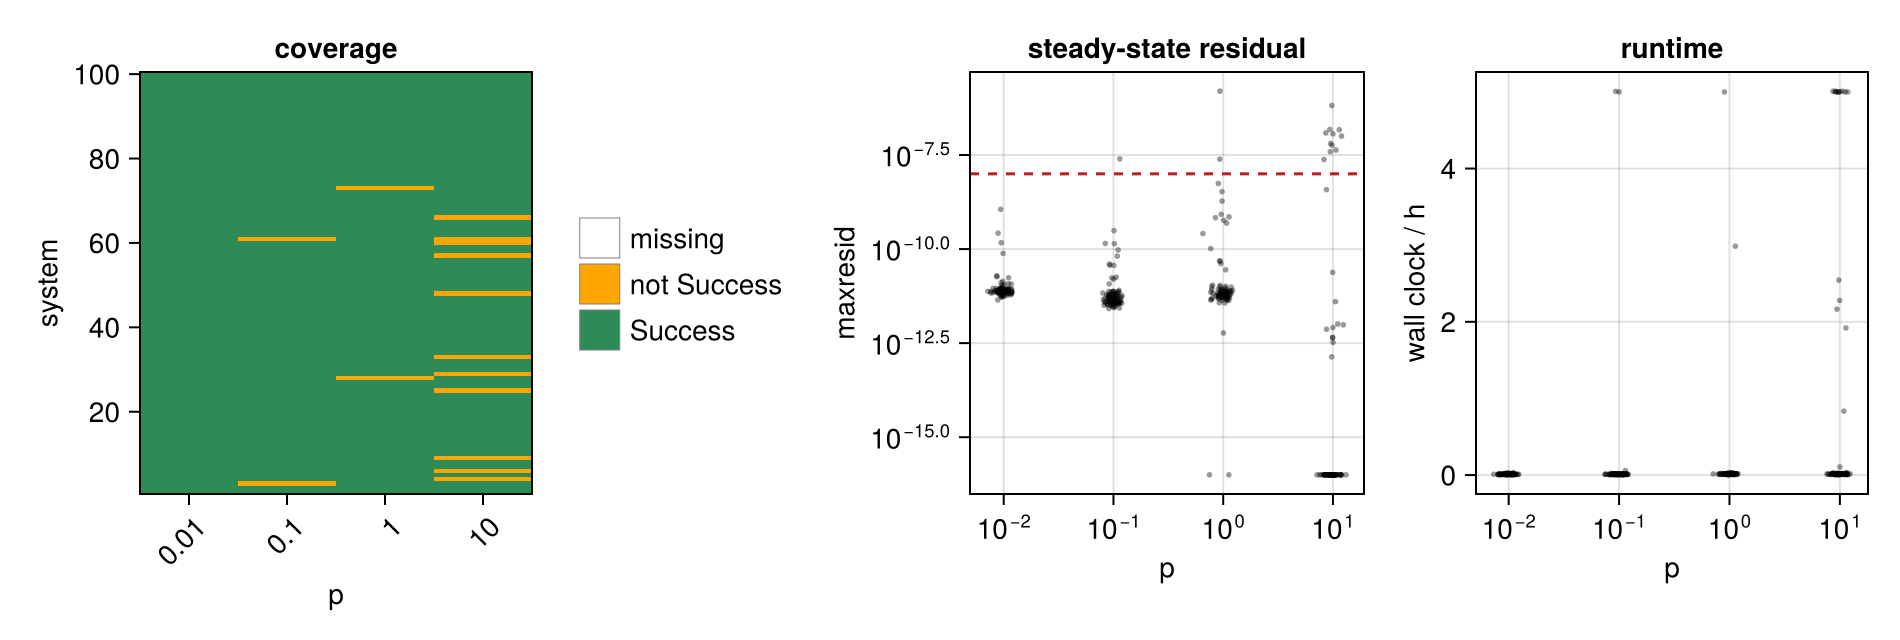

In [23]:
cov = fill(0, maximum(pde_df.sys_i), length(pvals))  # 0 missing, 1 non-Success, 2 Success
for r in eachrow(runs)
    j = findfirst(p -> isapprox(p, r.p), pvals)
    cov[r.gdf_row, j] = r.retcode == ReturnCode.Success ? 2 : 1
end

dfig = Figure(; size=(950, 320))

ax = Axis(dfig[1, 1]; xlabel="p", ylabel="system", title="coverage",
    xticklabelrotation=pi / 4)
heatmap!(ax, 1:length(pvals), 1:size(cov, 1), permutedims(cov);
    colormap=cgrad([:white, :orange, :seagreen], 3; categorical=true), colorrange=(-0.5, 2.5))
ax.xticks = (1:length(pvals), [@sprintf("%.3g", p) for p in pvals])
Legend(dfig[1, 2], [PolyElement(; color=c, strokecolor=:grey, strokewidth=0.5) for c in [:white, :orange, :seagreen]],
    ["missing", "not Success", "Success"]; framevisible=false)

ax = Axis(dfig[1, 3]; xscale=log10, yscale=log10, xlabel="p", ylabel="maxresid",
    title="steady-state residual")
scatter!(ax, runs.p .* (1 .+ 0.1 .* randn(nrow(runs))), max.(runs.maxresid, 1e-16); markersize=4, color=(:black, 0.4))
hlines!(ax, 1e-8; color=:firebrick, linestyle=:dash)

ax = Axis(dfig[1, 4]; xscale=log10, xlabel="p", ylabel="wall clock / h", title="runtime")
scatter!(ax, runs.p .* (1 .+ 0.1 .* randn(nrow(runs))), runs.realtime ./ 3600; markersize=4, color=(:black, 0.4))

Makie.save("figures/main3_diagnostics.pdf", dfig)
dfig

# Per-run metrics

Spatial *averages* rather than integrals: `L` differs between runs (each domain is sized to one peak of that run's own peak `k`), so `mean` over `x` is the comparable quantity and the integral is just `L` times it.

Peak region = the contiguous run of gridpoints above half max of the total strain biomass `B(x) = sum_i N_i(x)`, taken around the global max and wrapping over the periodic boundary.

In [24]:
"""
    fwhm_idxs(B)

Indices of the peak of the periodic profile `B`: the contiguous run of points
above half max, `(max + min) / 2`, containing the global maximum, wrapped over
the ends of the domain.
"""
function fwhm_idxs(B)
    n = length(B)
    half = (maximum(B) + minimum(B)) / 2
    imax = argmax(B)
    lo, hi = imax, imax
    while (hi - lo + 1) < n && B[mod1(lo - 1, n)] > half
        lo -= 1
    end
    while (hi - lo + 1) < n && B[mod1(hi + 1, n)] > half
        hi += 1
    end
    mod1.(lo:hi, n)
end

"""
    relamp(B)

Peak-to-trough amplitude of `B` relative to its mean; the flat/patterned test.
"""
relamp(B) = (maximum(B) - minimum(B)) / mean(B)

amp_thresh = 0.05  # below this a final state counts as unpatterned

0.05

In [25]:
runs.Bx = [vec(sum(view(u, 1:ns, :); dims=1)) for (u, ns) in zip(runs.final_state, runs.Ns)]  # B(x), total strain biomass at each gridpoint
runs.relamp = relamp.(runs.Bx)                        # (max - min) / mean of B(x), how strongly patterned the state is
runs.patterned = runs.relamp .> amp_thresh            # false when B(x) came out flat, ie no pattern formed
runs.pk_idxs = fwhm_idxs.(runs.Bx)                    # gridpoints inside the FWHM peak of B(x), wrapped over the boundary
runs.fwhm_frac = [length(is) / length(B) for (is, B) in zip(runs.pk_idxs, runs.Bx)]  # that peak's width as a fraction of L
runs.fwhm = runs.fwhm_frac .* runs.L                  # that peak's width in units of x

runs.s_hss = [h[1:ns] for (h, ns) in zip(runs.hss, runs.Ns)]              # per strain, its well-mixed steady state abundance (no space)
runs.s_glob = [vec(mean(view(u, 1:ns, :); dims=2)) for (u, ns) in zip(runs.final_state, runs.Ns)]  # per strain, mean over the whole domain
runs.s_peak = [vec(mean(view(u, 1:ns, is); dims=2)) for (u, is, ns) in zip(runs.final_state, runs.pk_idxs, runs.Ns)]  # per strain, mean inside the peak

runs.B_hss = sum.(runs.s_hss)                         # total biomass of the well-mixed steady state
runs.B_glob = sum.(runs.s_glob)                       # total biomass averaged over the whole domain, == mean(Bx)
runs.B_peak = sum.(runs.s_peak)                       # total biomass averaged inside the peak, == mean(Bx[pk_idxs])
runs.B_glob_rel = runs.B_glob ./ runs.B_hss           # whole-domain total, relative to that system's hss
runs.B_peak_rel = runs.B_peak ./ runs.B_hss           # peak total, relative to that system's hss

@show count(runs.patterned) count(.!runs.patterned) extrema(runs.relamp);
combine(groupby(runs, :p),
    nrow => :n,
    :patterned => count => :n_patterned,
    :fwhm_frac => (x -> quantile(x, 0.5)) => :fwhm_frac_med,
    :B_glob_rel => (x -> quantile(x, 0.5)) => :B_glob_rel_med,
    :B_peak_rel => (x -> quantile(x, 0.5)) => :B_peak_rel_med,
)

count(runs.patterned) = 391
count(.!(runs.patterned)) = 9
extrema(runs.relamp) = (NaN, NaN)

Row,p,n,n_patterned,fwhm_frac_med,B_glob_rel_med,B_peak_rel_med
,Float64,Int64,Int64,Float64,Float64,Float64
1,0.01,100,100,0.116,1.66578,5.84248
2,0.1,100,100,0.084,1.39437,6.37698
3,1.0,100,100,0.072,0.433765,4.60305
4,10.0,100,91,0.02,5.63821e-28,2.69681e-27


# Do some filtering
only take runs which did not get reinvasions and which showed a patterned state 

# Final states

Each panel is circularly shifted so the biomass peak sits in the middle; the shaded band is the FWHM peak region, dashed lines the homogeneous steady state.

In [26]:
"""
    plot_final_state!(where, r; title, hidex)

Strain and resource profiles of one run, shifted so the biomass peak is centred.
Thick black is the total strain biomass, dashed lines the homogeneous steady
state, the shaded band the FWHM peak region.
"""
function plot_final_state!(where, r; title="", hidex=false)
    ns, nr = r.Ns, r.Nr  # per system, after reduce_extinct
    scolors = Makie.resample_cmap(:viridis, max(ns, 2))
    rcolors = Makie.resample_cmap(:plasma, max(nr, 2))

    u, B = r.final_state, r.Bx
    n = size(u, 2)
    sh = div(n, 2) - argmax(B)
    uc, Bc = circshift(u, (0, sh)), circshift(B, sh)
    pk = sort(mod1.(r.pk_idxs .+ sh, n))
    xs = get_spatial_gridpoints_L(n, r.L)

    gl = GridLayout(where)
    axs = Axis(gl[1, 1]; ylabel="strains", title, titlesize=10)
    axr = Axis(gl[2, 1]; ylabel="resources", xlabel="x")
    linkxaxes!(axs, axr)
    hidexdecorations!(axs; grid=false)
    hidex && hidexdecorations!(axr; grid=false)
    rowgap!(gl, 4)

    for ax in (axs, axr)
        vspan!(ax, xs[first(pk)], xs[last(pk)]; color=(:grey, 0.2))
    end
    for i in 1:ns
        lines!(axs, xs, uc[i, :]; color=scolors[i], linewidth=0.7)
        hlines!(axs, r.hss[i]; color=scolors[i], linestyle=:dash, linewidth=0.4)
    end
    lines!(axs, xs, Bc; color=:black, linewidth=1.6)
    hlines!(axs, r.B_hss; color=:black, linestyle=:dash, linewidth=1.0)
    for a in 1:nr
        lines!(axr, xs, uc[ns+a, :]; color=rcolors[a], linewidth=0.7)
        hlines!(axr, r.hss[ns+a]; color=rcolors[a], linestyle=:dash, linewidth=0.4)
    end
    xlims!(axs, extrema(xs))

    axs, axr
end

"""
    plot_system_final_states(rs; kwargs...)

One column per run in `rs` (a system's rows, ordered by `p`).
"""
function plot_system_final_states(rs; width=250, height=170, kwargs...)
    fig = Figure(; size=(width * nrow(rs), 2 * height))
    for (j, r) in enumerate(eachrow(rs))
        plot_final_state!(fig[1, j], r;
            title=@sprintf("sys %d, p = %.3g\nrelamp %.2f, FWHM %.2f L", r.gdf_row, r.p, r.relamp, r.fwhm_frac),
            kwargs...)
    end
    fig
end

plot_system_final_states

ex_systems = [61, 35, 53]

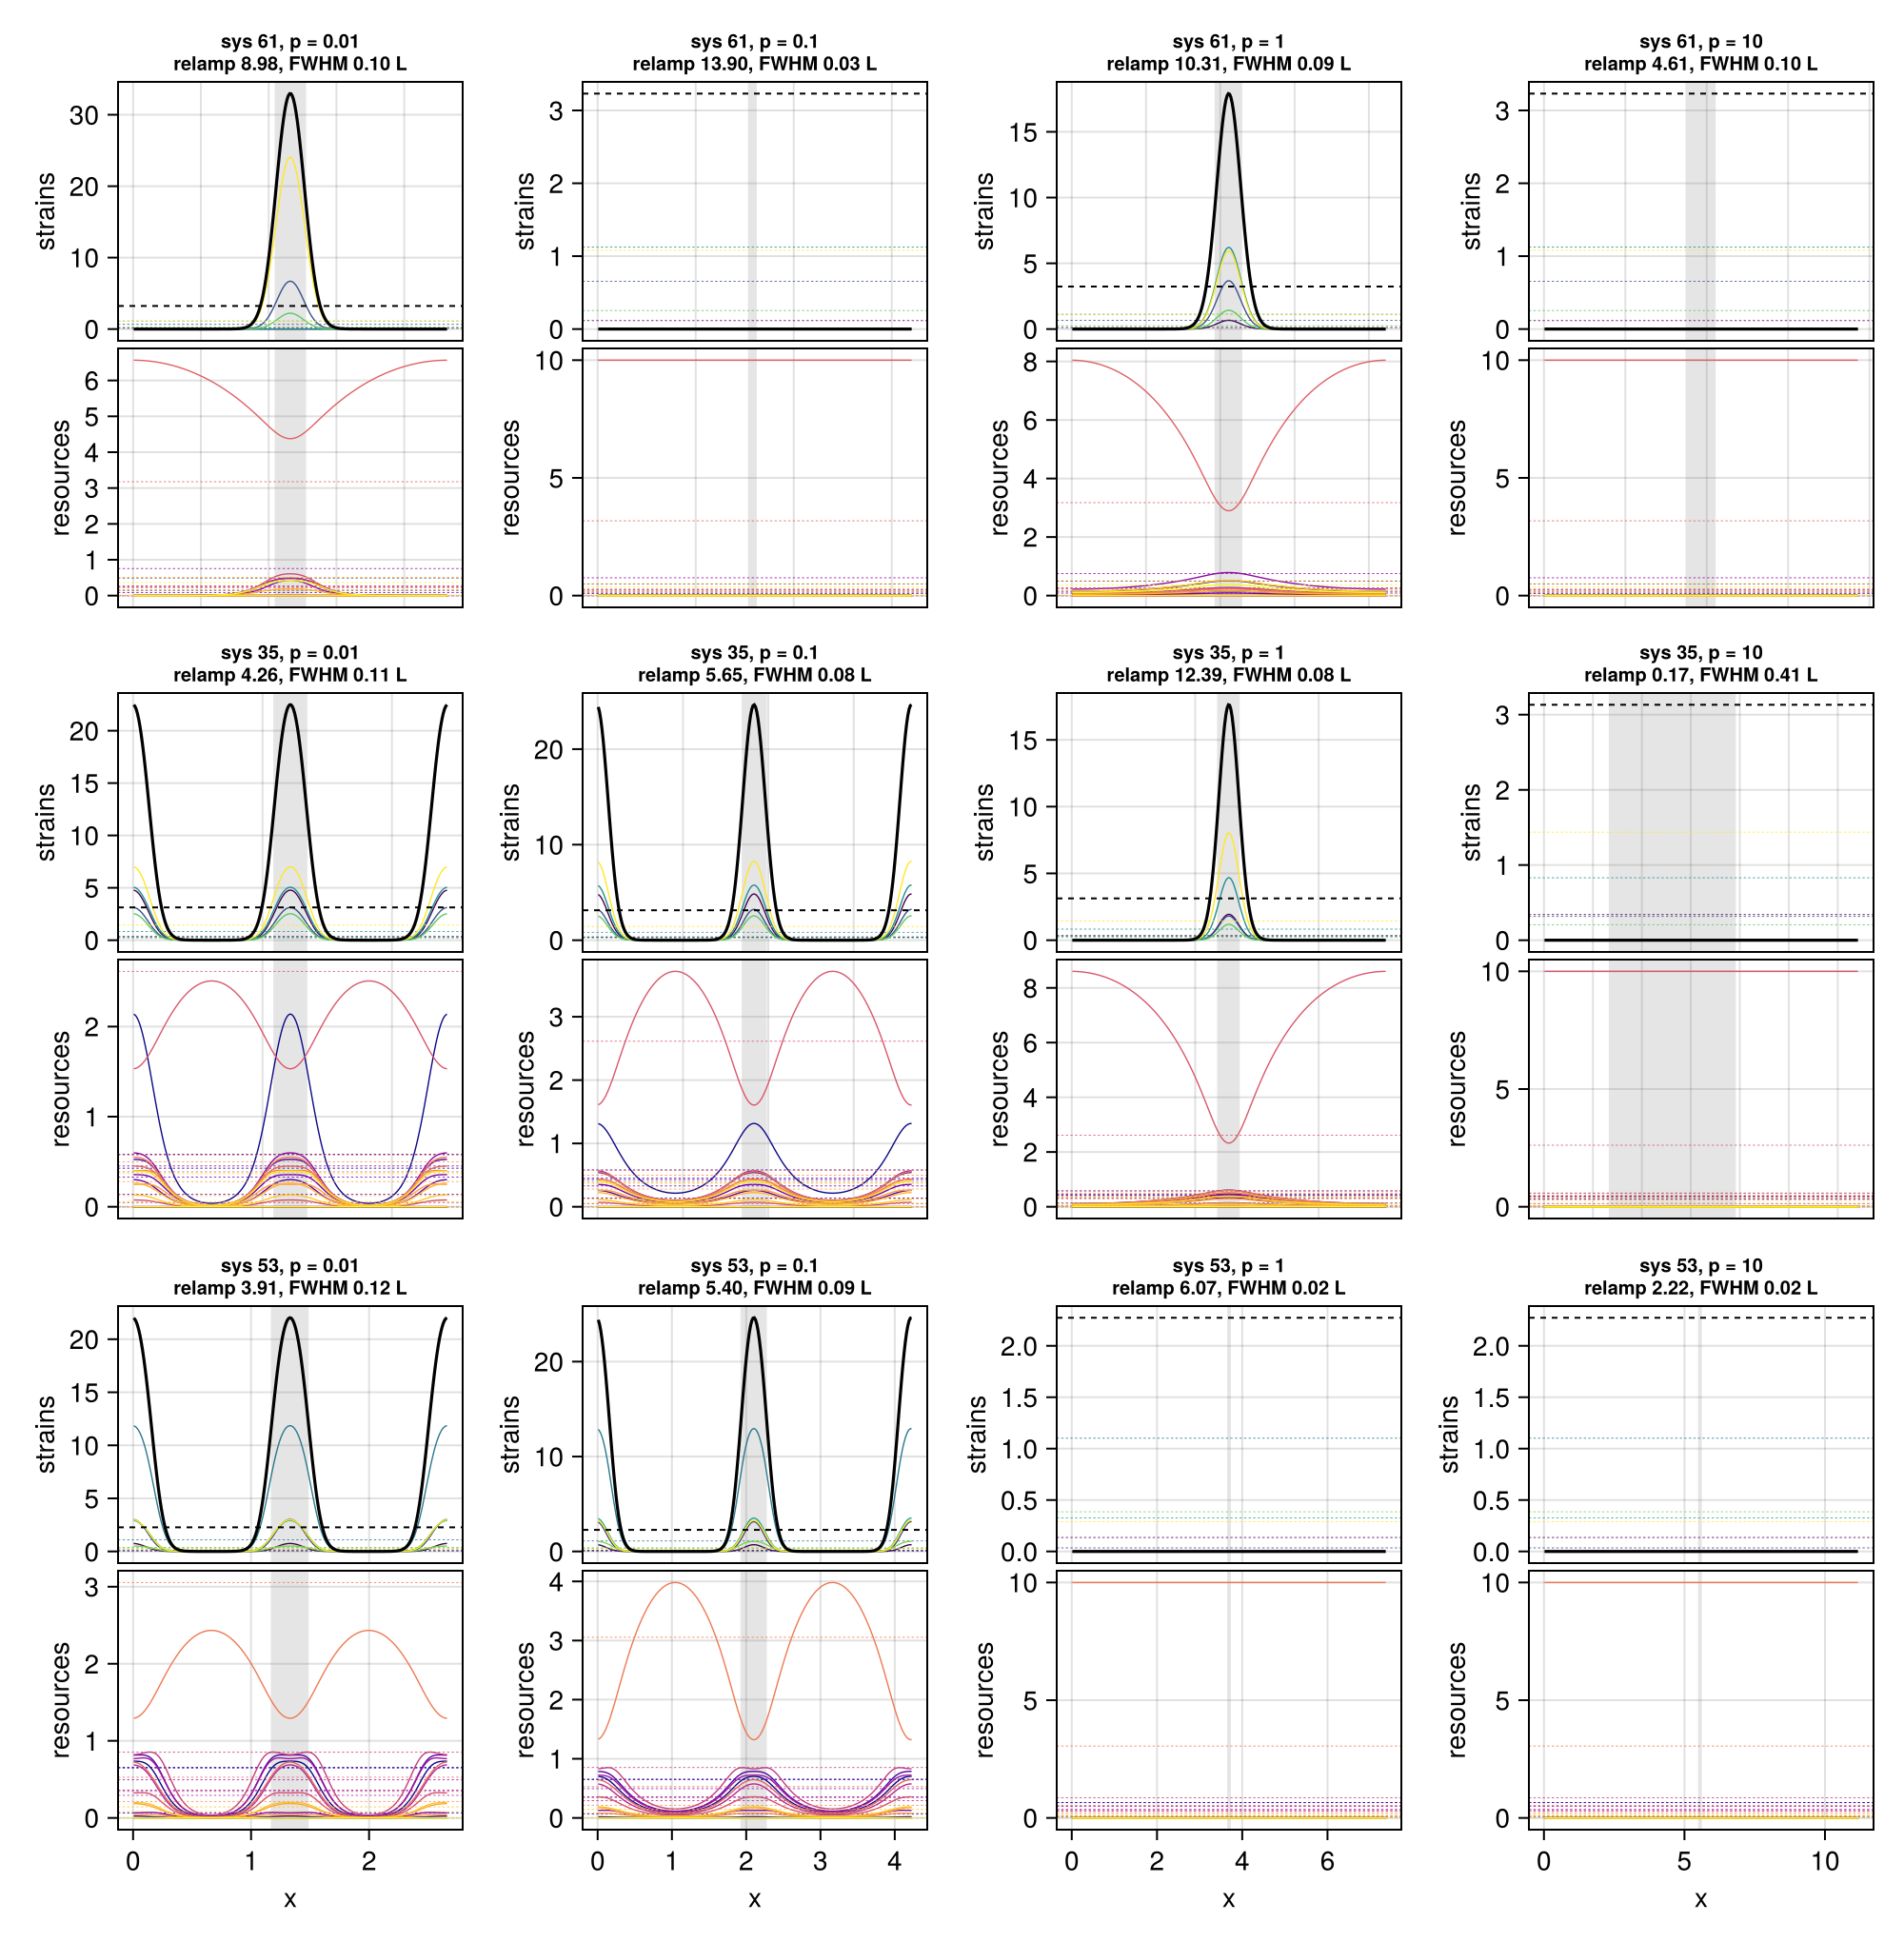

In [27]:
# three examples spanning the range of normalised whole-domain biomass at p = 0.1
ref = sort(runs[isapprox.(runs.p, 0.1), :], :B_glob_rel)
ex_systems = ref.gdf_row[[1, div(nrow(ref) + 1, 2), end]]

exfig = Figure(; size=(250 * length(pvals), 2 * 170 * length(ex_systems)))
for (i, s) in enumerate(ex_systems)
    rs = sort(runs[runs.gdf_row.==s, :], :p)
    for (j, r) in enumerate(eachrow(rs))
        plot_final_state!(exfig[i, j], r;
            title=@sprintf("sys %d, p = %.3g\nrelamp %.2f, FWHM %.2f L", r.gdf_row, r.p, r.relamp, r.fwhm_frac),
            hidex=(i != length(ex_systems)))
    end
end
Makie.save("figures/main3_final_states_examples.pdf", exfig)
@show ex_systems;
exfig

In [28]:
@showprogress for i in sys_rows
    fig = plot_system_final_states(sort(runs[runs.gdf_row.==i, :], :p))
    Makie.save((@sprintf "./figures/fss/row%04d.pdf" i), fig)
end

Progress: 100%|█████████████████████████████████████████| Time: 0:00:33

# Testing relative composition metrics

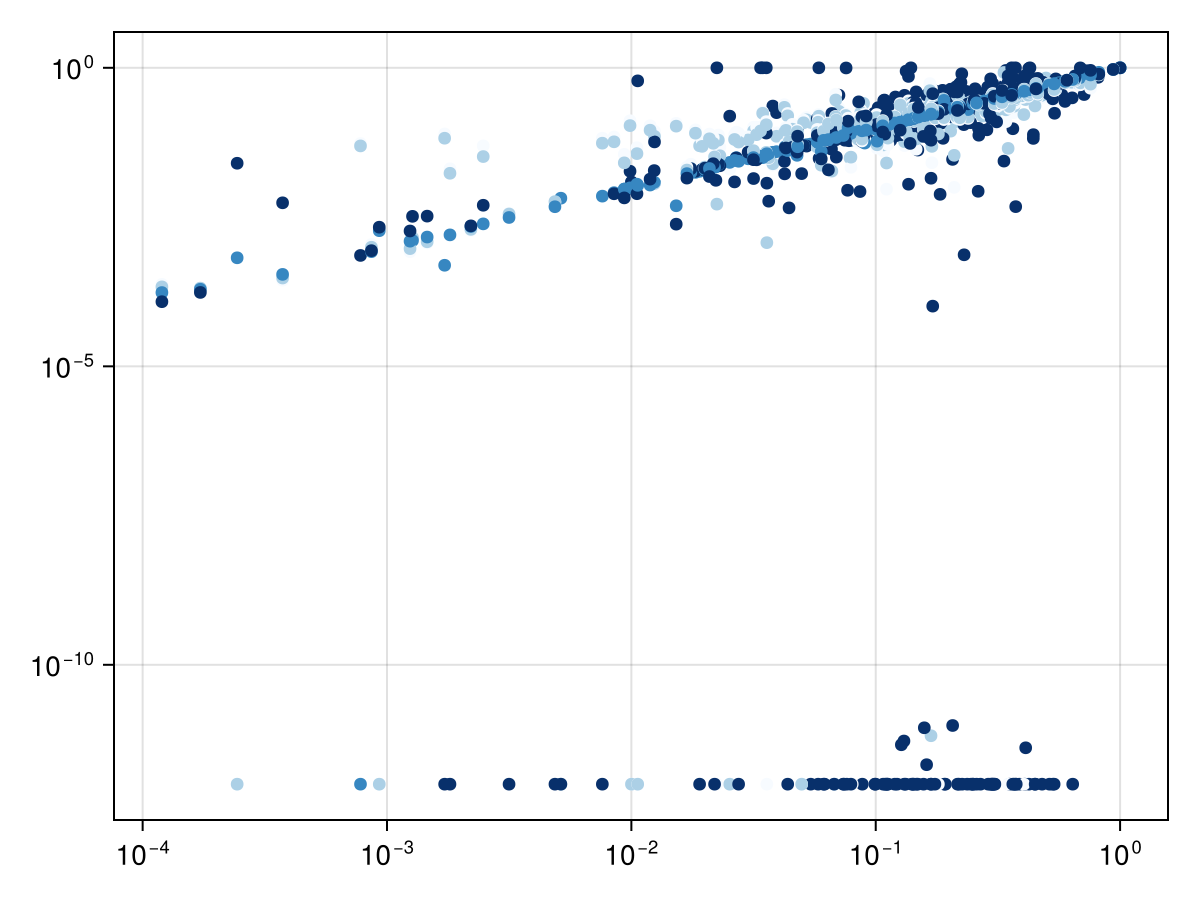

In [29]:
fig = Figure()
ax = Axis(fig[1,1];
    xscale=log10,
    yscale=log10,
)

pmin, pmax = extrema(log10.(smeta.ps))
pdelta = pmax - pmin
for ii in 1:nrow(runs)
    r = runs[ii,:];
    smeans_pde = r.s_glob  # strains only, this system's reduced Ns
    smeans_ode = r.s_hss;

    xxp = smeans_pde ./ sum(smeans_pde)
    xxo = smeans_ode ./ sum(smeans_ode)

    # scatter!(ax, smeans_ode, smeans_pde;
    scatter!(ax, clamp.(xxo, 1e-12, Inf), clamp.(xxp, 1e-12, Inf),
        color=get(ColorSchemes.Blues, (log10(r.p) - pmin) / pdelta)
    )
end

Makie.save("./figures/relabundances_scatter.pdf", fig)

# xlims!(ax, 1e-4, 10^0.5)
# ylims!(ax, 1e-4, 10^0.5)

fig

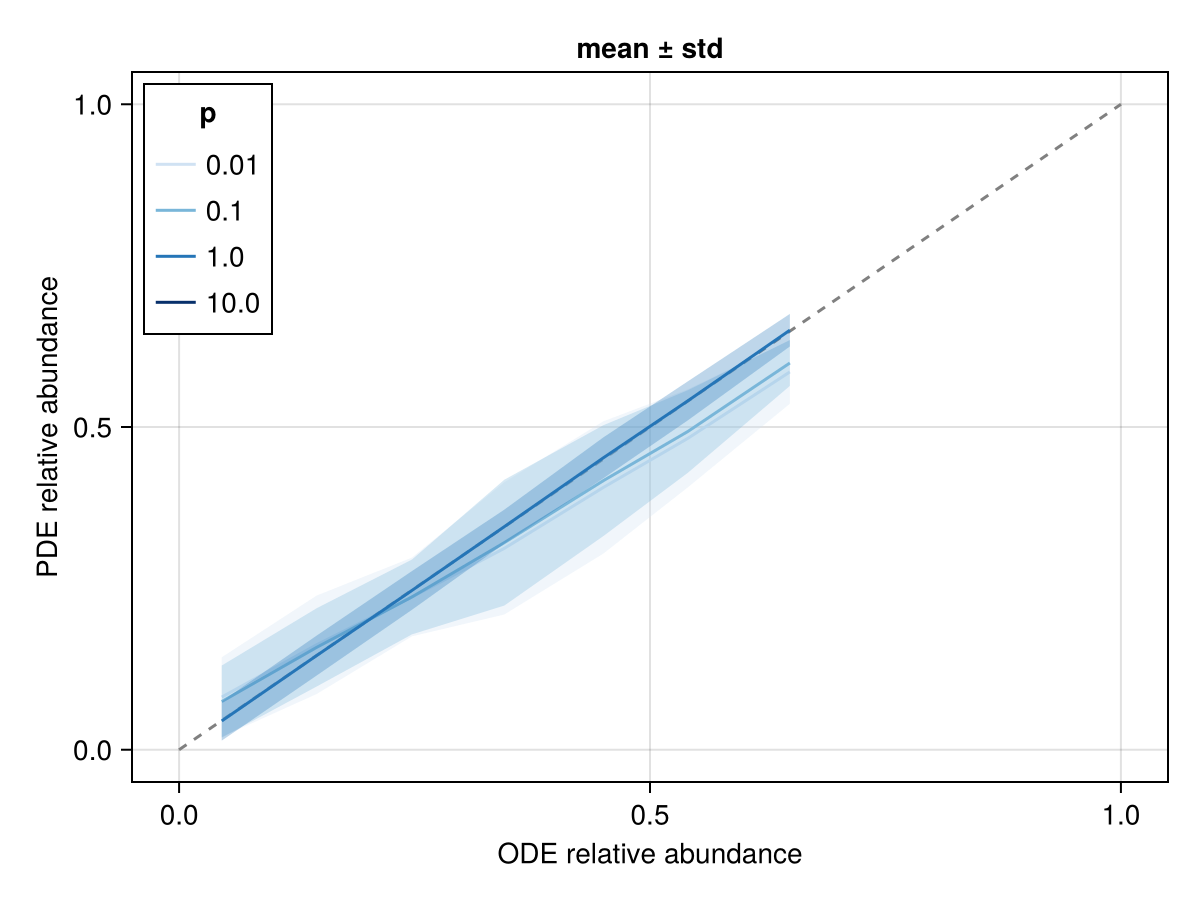

In [30]:
nbins = 10
minbin = 5

function relabunds(r)
    xxp, xxo = r.s_glob, r.s_hss  # strains only, this system's reduced Ns
    xxp ./ sum(xxp), xxo ./ sum(xxo)
end

all_xxo = reduce(vcat, [relabunds(r)[2] for r in eachrow(runs)])
edges = range(0, maximum(all_xxo); length=nbins + 1)

function plot_composition_band(spread; title)
    fig = Figure()
    ax = Axis(fig[1, 1]; title, xlabel="ODE relative abundance", ylabel="PDE relative abundance")

    pmin, pmax = extrema(log10.(smeta.ps))
    pdelta = pmax - pmin

    lines!(ax, [0, 1], [0, 1]; color=:gray, linestyle=:dash)
    for g in groupby(runs, :p)
        p = first(g.p)
        xp, xo = Float64[], Float64[]
        for r in eachrow(g)
            a, b = relabunds(r)
            append!(xp, a)
            append!(xo, b)
        end

        bin = clamp.(searchsortedlast.(Ref(edges), xo), 1, nbins)
        xc, mm, lo, hi = Float64[], Float64[], Float64[], Float64[]
        for b in 1:nbins
            sel = bin .== b
            count(sel) < minbin && continue
            y = xp[sel]
            mu = mean(y)
            d = spread(y)
            push!(xc, mean(xo[sel]))
            push!(mm, mu)
            push!(lo, mu - d)
            push!(hi, mu + d)
        end

        c = get(ColorSchemes.Blues, 0.2 + 0.8 * (log10(p) - pmin) / pdelta)
        band!(ax, xc, lo, hi; color=(c, 0.3))
        lines!(ax, xc, mm; color=c, label=string(round(p; sigdigits=2)))
    end
    axislegend(ax, "p"; position=:lt)

    fig
end

plot_composition_band(std; title="mean ± std")


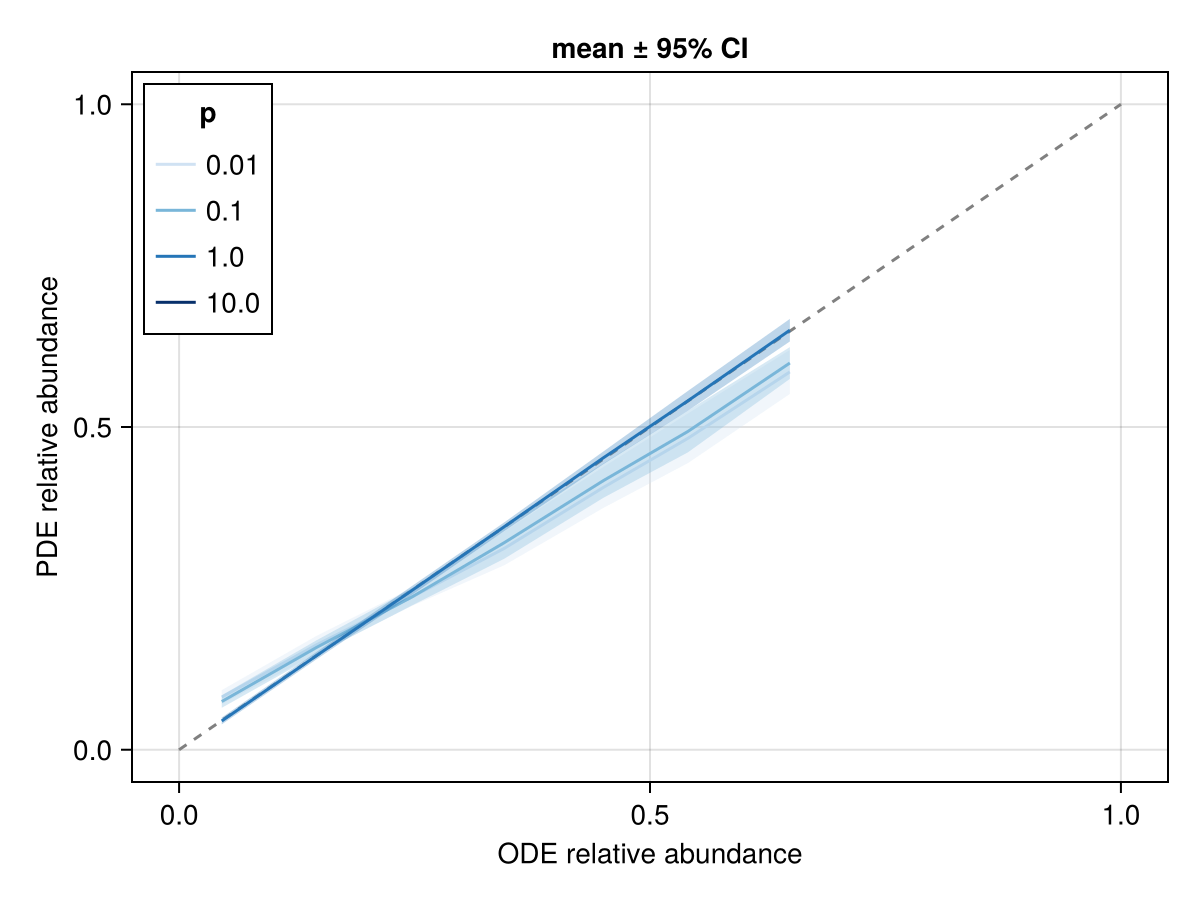

In [31]:
plot_composition_band(y -> 1.96 * std(y) / sqrt(length(y)); title="mean ± 95% CI")


In [32]:
xxs = []
for ii in 1:nrow(runs)
    r = runs[ii,:];
    smeans_pde = r.s_glob  # strains only, this system's reduced Ns
    smeans_ode = r.s_hss;

    xxp = smeans_pde ./ sum(smeans_pde)
    xxo = smeans_ode ./ sum(smeans_ode)

    push!(xxs, dot(xxp, xxo))
end

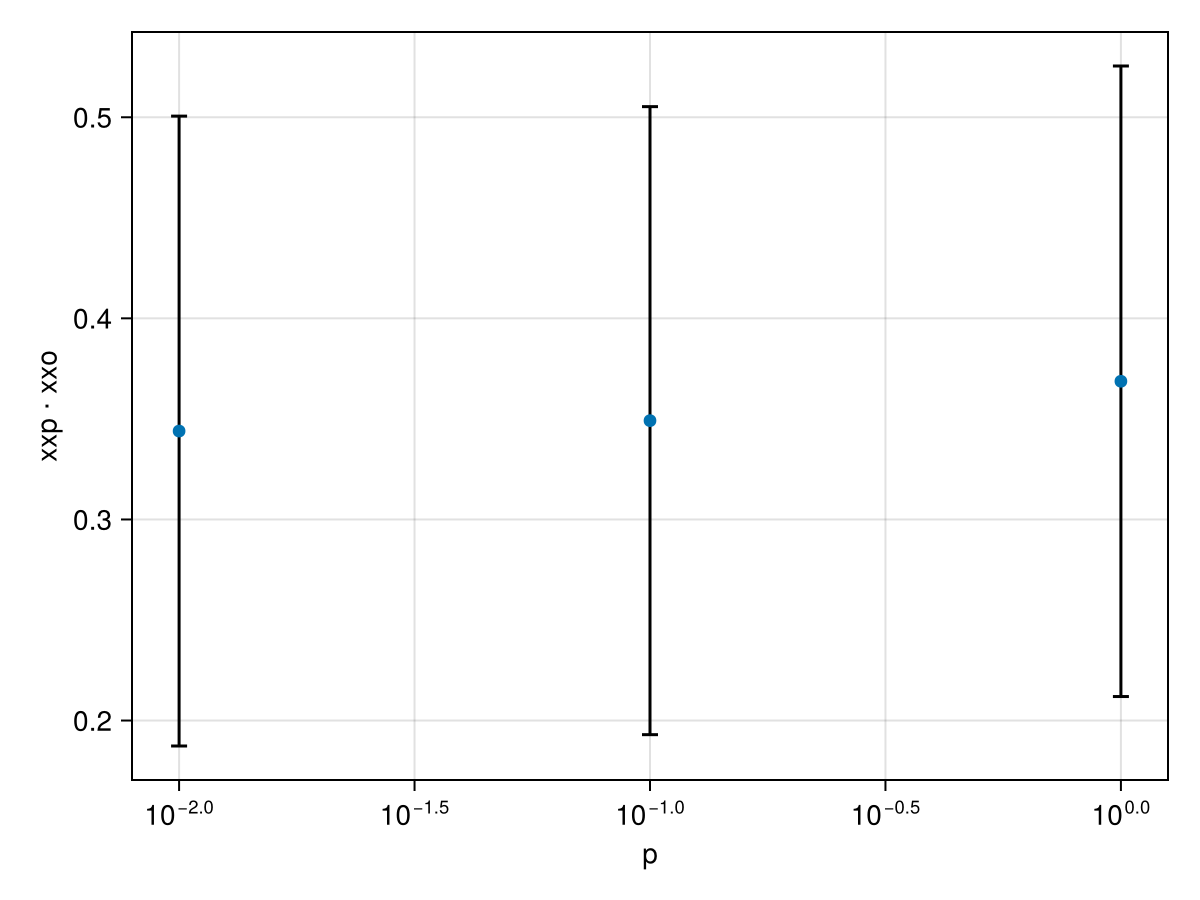

In [33]:
runs.xxs = xxs;
gbp = groupby(runs, :p);

ps = [g.p[1] for g in gbp]
mm = [mean(float.(g.xxs)) for g in gbp]
ss = [std(float.(g.xxs)) for g in gbp]

fig = Figure()
ax = Axis(fig[1, 1]; xscale=log10, xlabel="p", ylabel="xxp ⋅ xxo")
errorbars!(ax, ps, mm, ss; whiskerwidth=8, color=:black)
scatter!(ax, ps, mm)

fig

Row,p,slope,intercept,r2
,Float64,Float64,Float64,Float64
1,0.01,0.832895,0.0373837,0.817559
2,0.1,0.868755,0.0293612,0.870852
3,1.0,1.00441,-0.000986224,0.998478
4,10.0,NaN,NaN,NaN


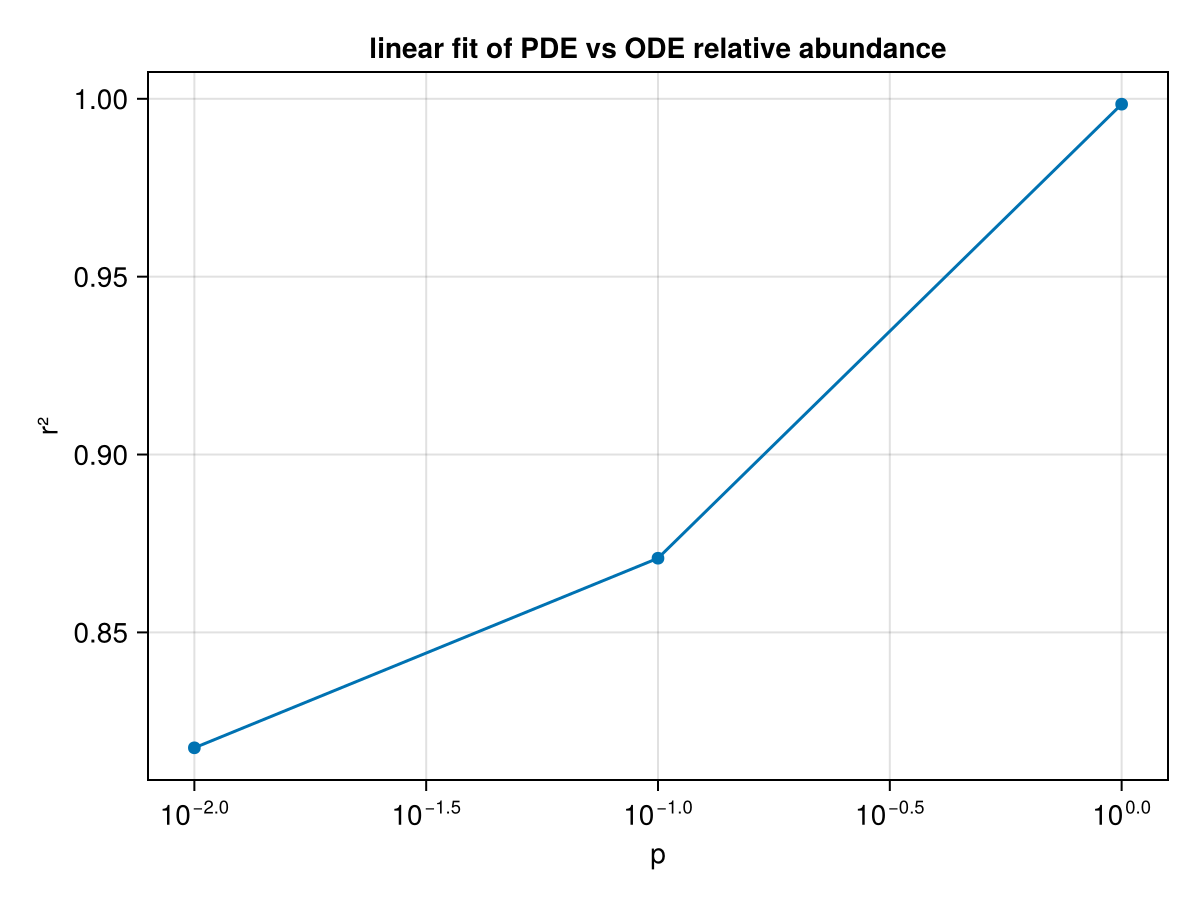

In [34]:
ps_fit, slopes, intercepts, r2s = Float64[], Float64[], Float64[], Float64[]
for g in groupby(runs, :p)
    xo, xp = Float64[], Float64[]
    for r in eachrow(g)
        a, b = relabunds(r)  # (pde, ode)
        append!(xp, a)
        append!(xo, b)
    end
    dxo, dxp = xo .- mean(xo), xp .- mean(xp)
    b1 = sum(dxo .* dxp) / sum(abs2, dxo)
    push!(ps_fit, g.p[1])
    push!(slopes, b1)
    push!(intercepts, mean(xp) - b1 * mean(xo))
    push!(r2s, cor(xo, xp)^2)
end

fig = Figure()
ax = Axis(fig[1, 1]; xscale=log10, xlabel="p", ylabel="r²",
    title="linear fit of PDE vs ODE relative abundance")
lines!(ax, ps_fit, r2s)
scatter!(ax, ps_fit, r2s)

display(DataFrame(; p=ps_fit, slope=slopes, intercept=intercepts, r2=r2s))
fig

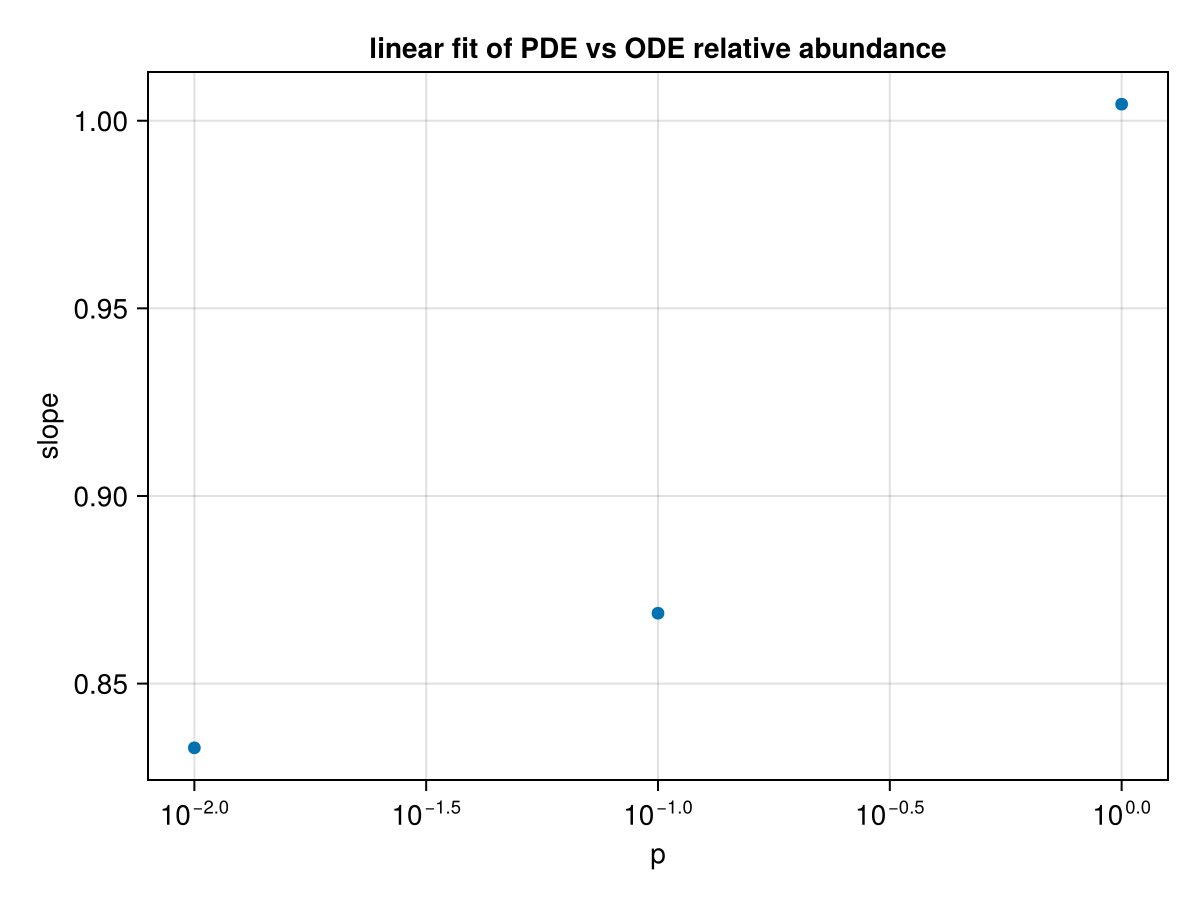

In [35]:
fig = Figure()
ax = Axis(fig[1, 1]; xscale=log10, xlabel="p", ylabel="slope",
    title="linear fit of PDE vs ODE relative abundance")
# lines!(ax, ps_fit, r2s)
scatter!(ax, ps_fit, slopes)

fig

# Extinction flips, hss vs PDE


In [36]:
ext_thresh = 1e-12  # strain abundance at or below this counts as extinct

alive_ode = [s .> ext_thresh for s in runs.s_hss]   # homogeneous steady state
alive_pde = [s .> ext_thresh for s in runs.s_glob]  # PDE, mean over the whole domain

runs.n_alive_ode = count.(alive_ode)
runs.n_alive_pde = count.(alive_pde)
runs.n_revived = [count(p .& .!o) for (o, p) in zip(alive_ode, alive_pde)]  # extinct in hss, alive in PDE
runs.n_died = [count(o .& .!p) for (o, p) in zip(alive_ode, alive_pde)]     # alive in hss, extinct in PDE

xx = combine(groupby(runs, :p),
    nrow => :n,
    :n_alive_ode => mean => :alive_ode_mean,
    :n_alive_pde => mean => :alive_pde_mean,
    :n_revived => mean => :revived_mean,
    :n_died => mean => :died_mean,
    :n_revived => (x -> count(>(0), x)) => :n_runs_revived,
    :n_died => (x -> count(>(0), x)) => :n_runs_died,
)

Row,p,n,alive_ode_mean,alive_pde_mean,revived_mean,died_mean,n_runs_revived,n_runs_died
,Float64,Int64,Float64,Float64,Float64,Float64,Int64,Int64
1,0.01,100,4.47,4.33,0.0,0.14,0,10
2,0.1,100,4.47,4.36,0.0,0.11,0,8
3,1.0,100,4.47,4.34,0.0,0.13,0,3
4,10.0,100,4.47,0.73,0.0,3.74,0,87


In [37]:
gbp = groupby(runs, :p)
g = gbp[1];

In [38]:
cms = [countmap(g.n_revived) for g in gbp]

4-element Vector{Dict{Int64, Int64}}:
 Dict(0 => 100)
 Dict(0 => 100)
 Dict(0 => 100)
 Dict(0 => 100)

In [39]:
get(cms[1], 8, 0)

0

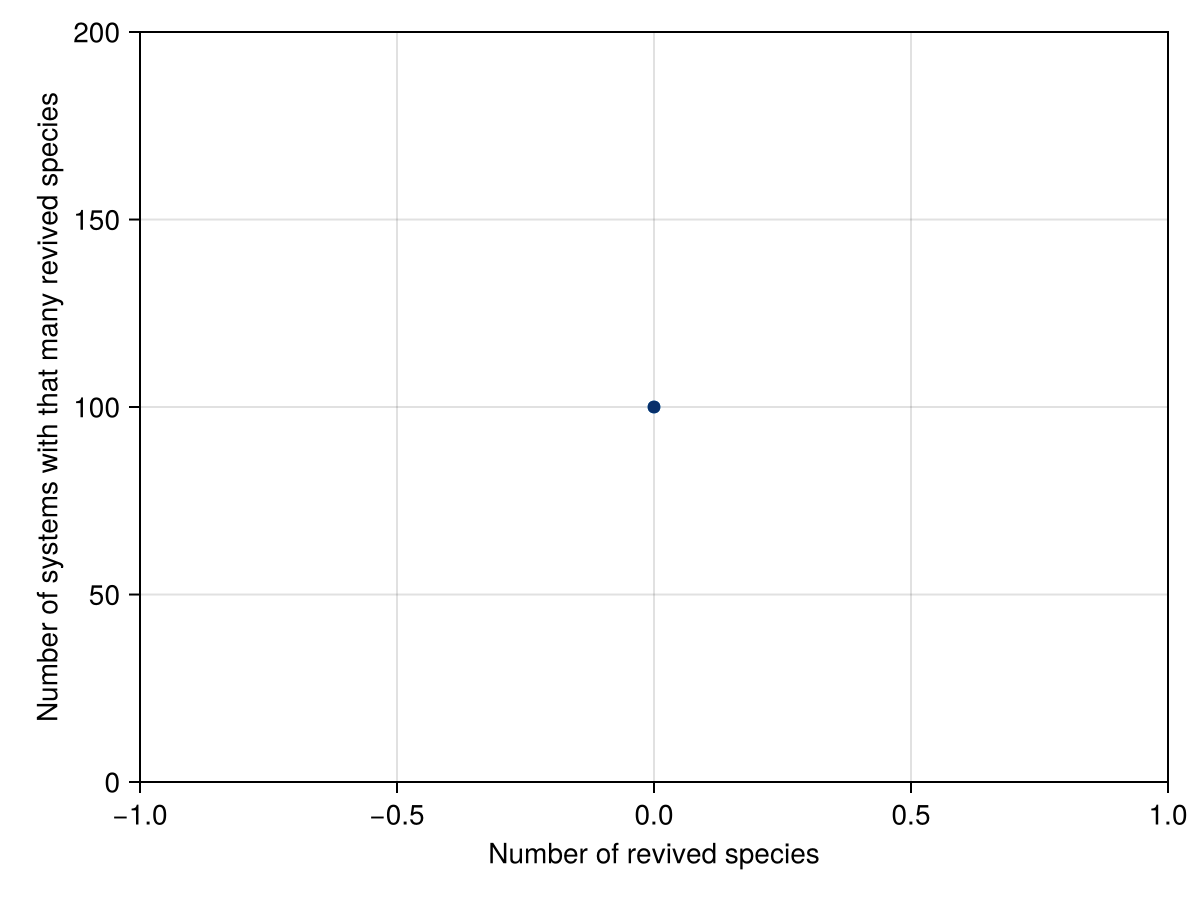

In [40]:
nmax = maximum(maximum, keys.(cms))

fig = Figure()
ax = Axis(fig[1,1];
    xlabel="Number of revived species",
    ylabel="Number of systems with that many revived species",
    # yscale=log10,
)

xs = 0:nmax
pmin, pmax = extrema(log10.(smeta.ps))
pdelta = pmax - pmin
for (g, cm) in zip(gbp, cms)
    p = g.p[1]
    ys = [get(cm, x, 0) for x in xs]
    scatterlines!(ax, xs, ys;
        color=get(ColorSchemes.Blues, (log10(p) - pmin) / pdelta)
    )
end

fig

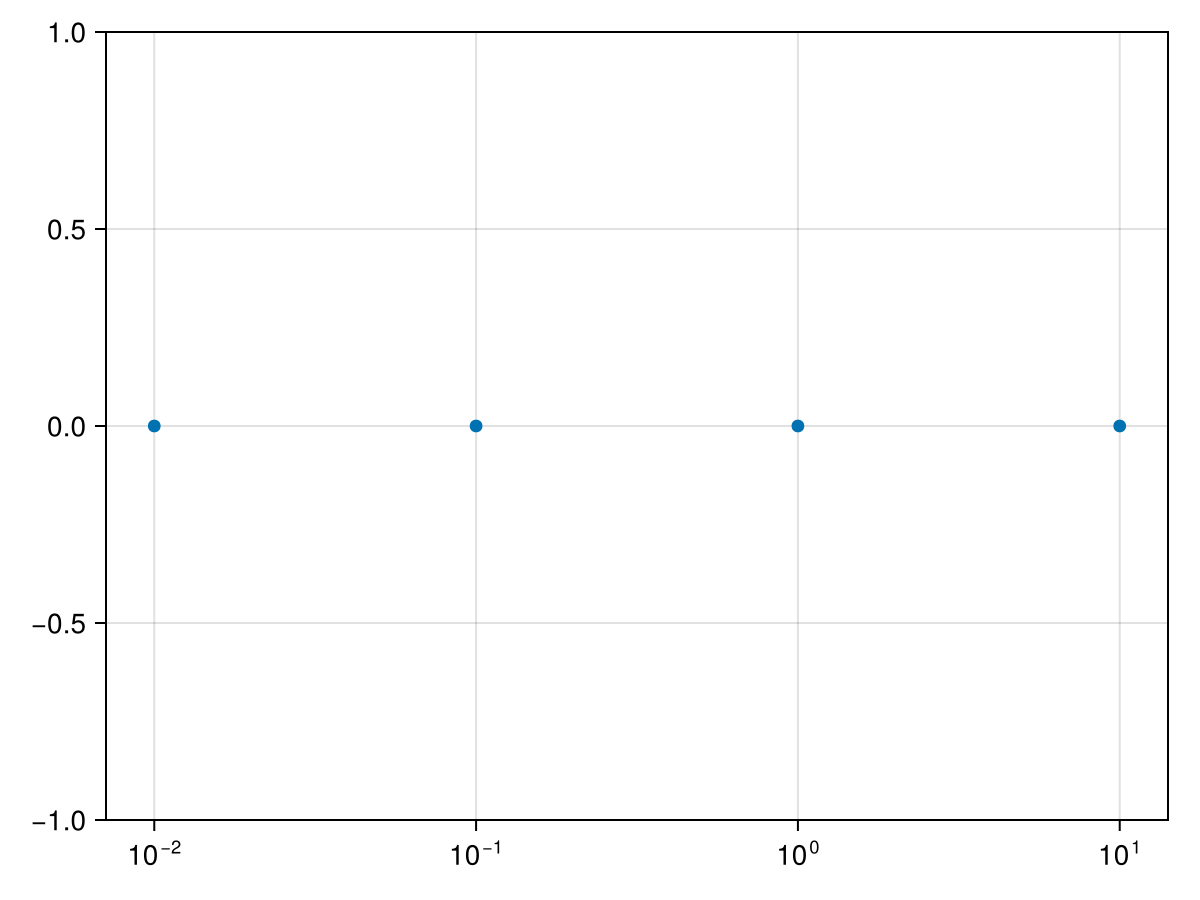

In [41]:
scatter(xx.p, xx.n_runs_revived ./ 100;
    axis=(; xscale=log10)
)

In [42]:
hist(runs[runs.p .== smeta.ps[end-4],:].n_revived)

LoadError: BoundsError: attempt to access 4-element Vector{Float64} at index [0]

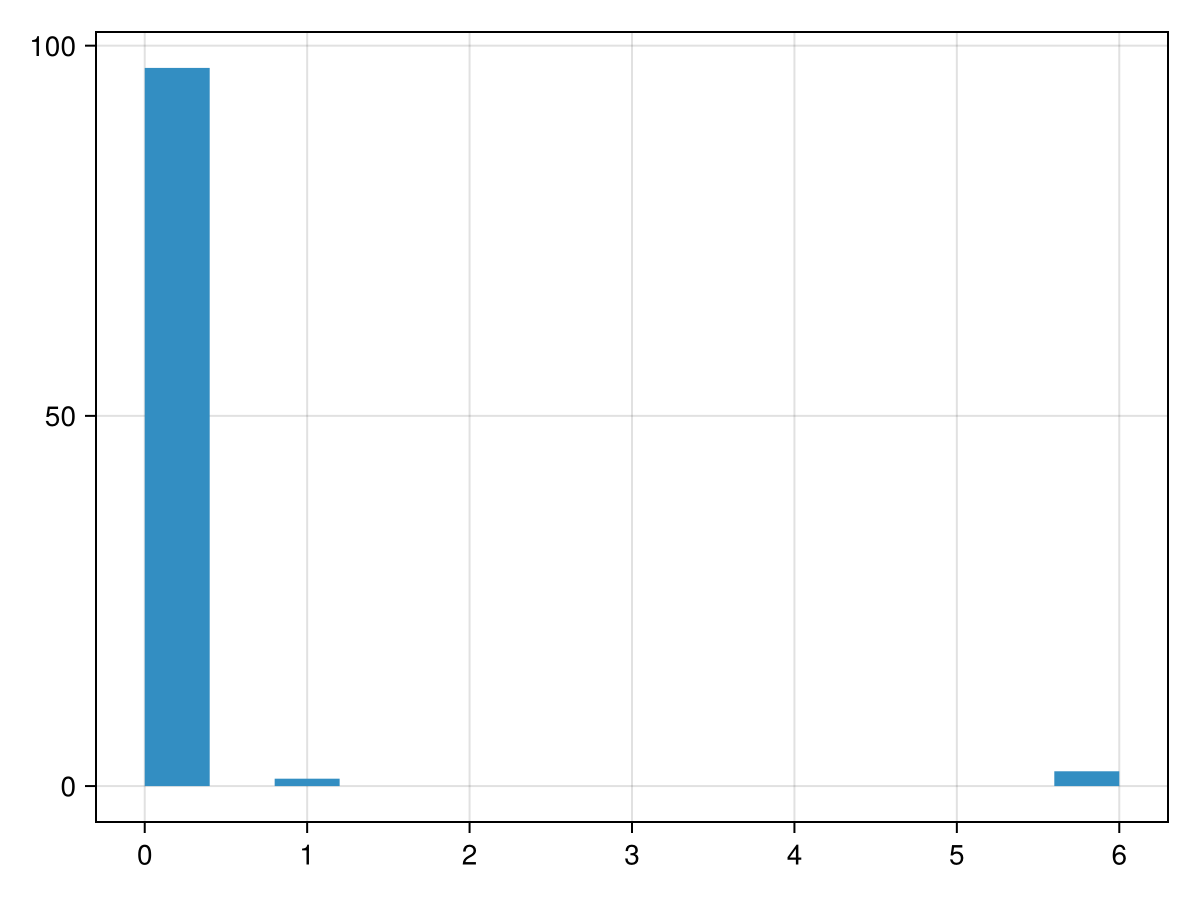

In [43]:
hist(runs[runs.p .== smeta.ps[end-1],:].n_died)

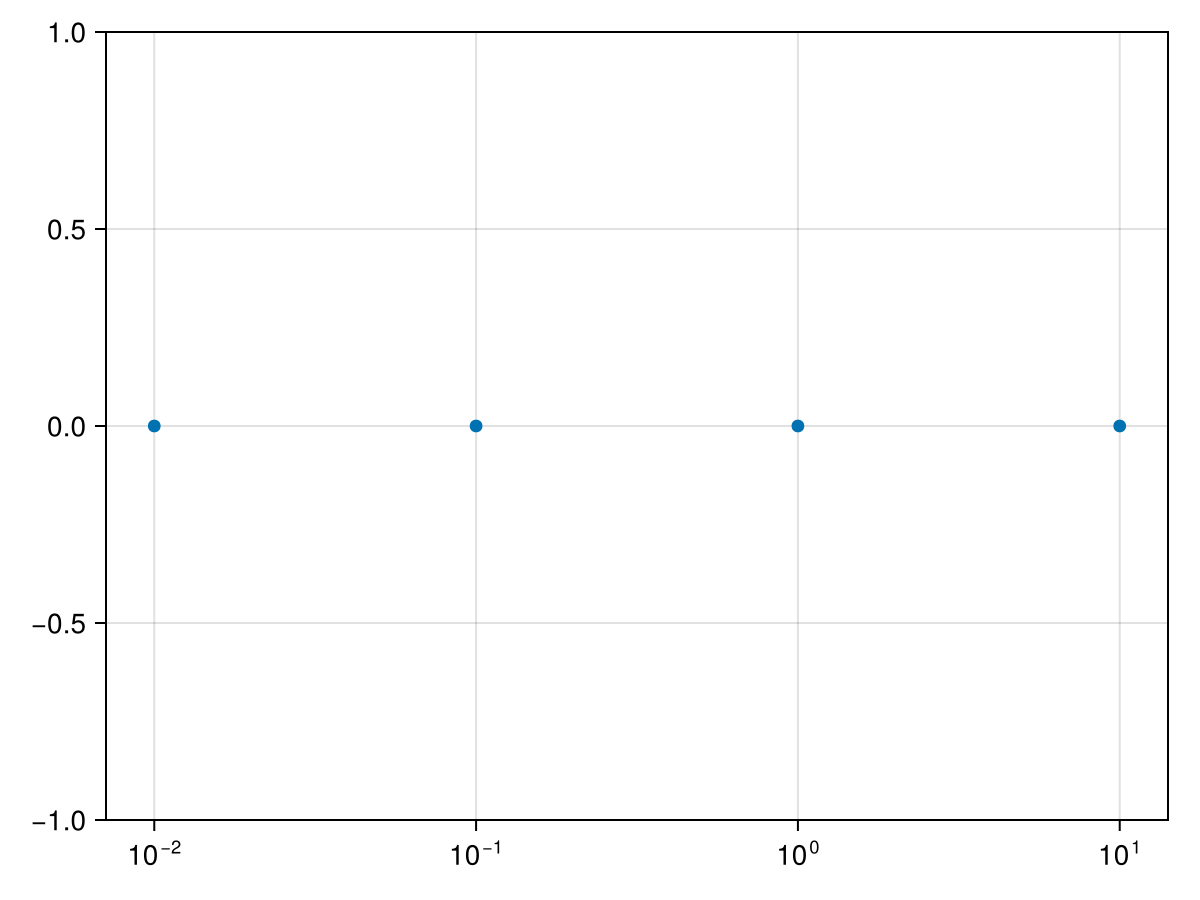

In [44]:
scatter(xx.p, xx.revived_mean;
    axis=(; xscale=log10)
)

# Entropy

Strain-only Shannon entropy of the well-mixed steady state and of the domain-averaged PDE final state.

In [45]:
"""
    shannon(s)

Shannon entropy in nats of the abundance vector `s`, normalised to fractions.
"""
function shannon(s)
    tot = sum(s)
    h = 0.0
    for x in s
        f = x / tot
        f > 0 && (h -= f * log(f))
    end
    h
end

runs.H_ode = shannon.(runs.s_hss)    # well-mixed steady state
runs.H_pde = shannon.(runs.s_glob)   # PDE, mean over the whole domain
runs.dH = runs.H_pde .- runs.H_ode

combine(groupby(runs, :p),
    nrow => :n,
    :H_ode => mean => :H_ode_mean,
    :H_pde => mean => :H_pde_mean,
    :dH => mean => :dH_mean,
    :dH => std => :dH_std,
)

Row,p,n,H_ode_mean,H_pde_mean,dH_mean,dH_std
,Float64,Int64,Float64,Float64,Float64,Float64
1,0.01,100,1.18166,1.2277,0.046034,0.159784
2,0.1,100,1.18166,1.22625,0.0445894,0.135276
3,1.0,100,1.18166,1.17819,-0.00346773,0.0182498
4,10.0,100,1.18166,0.843557,-0.338104,0.461707


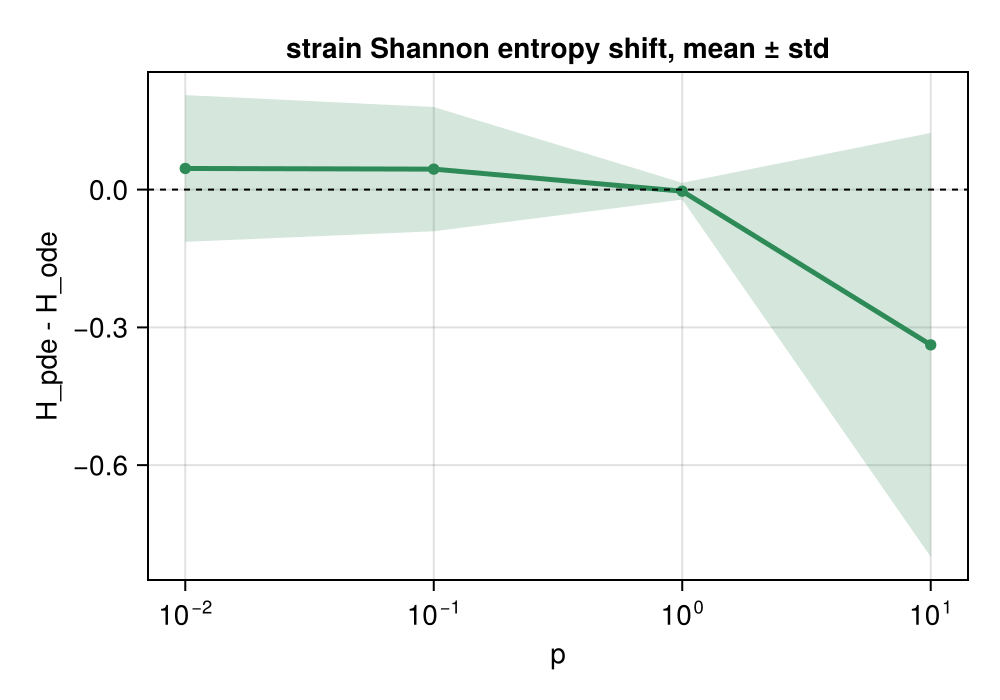

In [46]:
efig = Figure(; size=(500, 350))
ax = Axis(efig[1, 1]; xscale=log10, xlabel="p", ylabel="H_pde - H_ode",
    title="strain Shannon entropy shift, mean ± std")

dH_by_p = [runs[isapprox.(runs.p, p), :dH] for p in pvals]
dH_mean, dH_std = mean.(dH_by_p), std.(dH_by_p)

band!(ax, pvals, dH_mean .- dH_std, dH_mean .+ dH_std; color=(:seagreen, 0.2))
lines!(ax, pvals, dH_mean; color=:seagreen, linewidth=2.5)
scatter!(ax, pvals, dH_mean; color=:seagreen, markersize=8)
hlines!(ax, 0.0; color=:black, linestyle=:dash, linewidth=1)

Makie.save("figures/main3_entropy_shift.pdf", efig)
efig

# Jensen-Shannon

In [47]:
"""
    jsd(p, q)

Jensen-Shannon divergence in nats between the discrete probability
distributions `p` and `q`, each given as a vector of probabilities over the
same values. Both are normalised to sum to 1 first.
"""
function jsd(p, q)
    length(p) == length(q) || throw(DimensionMismatch("p and q must have the same length"))
    sp, sq = sum(p), sum(q)
    d = 0.0
    for (pi, qi) in zip(p, q)
        a, b = pi / sp, qi / sq
        m = (a + b) / 2
        a > 0 && (d += a * log(a / m) / 2)
        b > 0 && (d += b * log(b / m) / 2)
    end
    d
end

jsd